## Libraries

In [87]:
import os
import glob
import warnings
from tqdm import tqdm_notebook as tqdm
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import geopandas as gpd
from osgeo import gdal
import xarray as xr
import rioxarray as rxr
import rasterio
from rasterio.warp import reproject, Resampling, calculate_default_transform
from matplotlib import pyplot as plt
import seaborn as sns
%matplotlib inline
from tqdm import tqdm_notebook as tqdm
import json 

## Data processing

In [88]:
import re
def insert_space(text):
    return re.sub(r'([a-z](?=[A-Z])|[A-Z](?=[A-Z][a-z]))', r'\1 ', text)

poly = gpd.read_file('D:\Work\ADB\SAR\shapefiles\gadm41_VNM_1.json')
poly['VARNAME_1'] = poly['VARNAME_1'].apply(insert_space)
poly

,GID_1,GID_0,COUNTRY,NAME_1,VARNAME_1,NL_NAME_1,TYPE_1,ENGTYPE_1,CC_1,HASC_1,ISO_1,geometry
0,VNM.1_1,VNM,Vietnam,AnGiang,An Giang,NA,Tỉnh,Province,NA,VN.AG,VN-44,"MULTIPOLYGON (((105.54860 10.42950, 105.54950 ..."
1,VNM.7_1,VNM,Vietnam,BàRịa-VũngTàu,Ba Ria-Vung Tau,NA,Tỉnh,Province,NA,VN.BV,NA,"MULTIPOLYGON (((107.09010 10.32400, 107.08890 ..."
2,VNM.3_1,VNM,Vietnam,BắcGiang,Bac Giang,NA,Tỉnh,Province,NA,VN.BG,NA,"MULTIPOLYGON (((106.28380 21.13230, 106.27340 ..."
3,VNM.4_1,VNM,Vietnam,BắcKạn,Bac Kan,NA,Tỉnh,Province,NA,VN.BK,NA,"MULTIPOLYGON (((105.87240 21.85580, 105.86290 ..."
4,VNM.2_1,VNM,Vietnam,BạcLiêu,Bac Lieu,NA,Tỉnh,Province,NA,VN.BL,NA,"MULTIPOLYGON (((105.42440 9.02130, 105.41640 9..."
...,...,...,...,...,...,...,...,...,...,...,...,...
58,VNM.59_1,VNM,Vietnam,TràVinh,Tra Vinh,NA,Tỉnh,Province,NA,VN.TV,NA,"MULTIPOLYGON (((106.41350 9.52920, 106.40880 9..."
59,VNM.60_1,VNM,Vietnam,TuyênQuang,Tuyen Quang,NA,Tỉnh,Province,NA,VN.TQ,NA,"MULTIPOLYGON (((105.51040 21.60470, 105.51410 ..."
60,VNM.61_1,VNM,Vietnam,VĩnhLong,Vinh Long,NA,Tỉnh,Province,NA,VN.VL,NA,"MULTIPOLYGON (((106.06320 9.94750, 106.06270 9..."
61,VNM.62_1,VNM,Vietnam,VĩnhPhúc,Vinh Phuc,NA,Tỉnh,Province,NA,VN.VC,NA,"MULTIPOLYGON (((105.57130 21.16150, 105.53360 ..."


In [5]:
season = 'early_spring'

paths = glob.glob(f'D:\Work\ADB\SAR\datasets/seasonal/{season}/*.json')
paths

['D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2017.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2018.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2019.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2020.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2021.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.10_1_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2017.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2018.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2019.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2020.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2021.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.11_1_2022.json',
 'D:\\Work\\ADB\\SAR\\datasets/seasonal/early_spring\\VNM.12_1_2017.json',
 'D:\\Work\\ADB\\SAR\\dat

In [89]:

def preprocess_ee(season):

    file_paths = glob.glob(f'D:\Work\ADB\SAR\datasets/seasonal/{season}/*.json')
    assert len(file_paths) > 0

    list_gid_1 = []
    list_date = []
    list_dprvi = []
    list_rvi = []
    list_vvvh = []
    list_vhvv = []
    list_vv = []
    list_vh = []

    

    for path in tqdm(file_paths):
        with open(path, 'r') as in_file:
            j = json.load(in_file)
        list_gid_1.append(j['province_id'])
        list_date.append(j['date'])
        list_dprvi.append(j['DPRVI_mean'])
        list_rvi.append(j['RVI_mean'])
        list_vvvh.append(j['VVVH_mean'])
        list_vhvv.append(j['VHVV_mean'])
        list_vv.append(j['VV'])
        list_vh.append(j['VH'])

    df = pd.DataFrame({'GID_1': list_gid_1,
                    'date': list_date,
                    'DPRVI_mean': list_dprvi,
                    'RVI_mean': list_rvi,
                    'VHVV_mean': list_vhvv,
                    'VVVH_mean': list_vvvh,
                    'VV': list_vv,
                    'VH': list_vh})
    df = df.sort_values(by=['GID_1', 'date'])
    df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
    df = df.rename({'VARNAME_1': 'Province'}, axis=1)
    df['year'] = df['date'].str[:4]
    df['year'] = df['year'].astype(int)
    df = df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean', 
                                            'RVI_mean': 'mean',
                                            'VH': 'mean',
                                            'VV': 'mean',
                                            'VHVV_mean': 'mean',
                                            'VVVH_mean': 'mean'}).reset_index()
    df['season'] = season
    return df


In [90]:
ep_df = preprocess_ee('early_spring')
lp_df = preprocess_ee('late_spring')
ma_df = preprocess_ee('main_autumn')
la_df = preprocess_ee('late_autumn')
w_df = preprocess_ee('winter')

  0%|          | 0/378 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

  0%|          | 0/378 [00:00<?, ?it/s]

In [91]:
p_df = pd.concat([ep_df, lp_df], axis=0).reset_index(drop=True)
p_df = p_df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean',
                                               'RVI_mean': 'mean',
                                               'VH': 'mean',
                                               'VV': 'mean',
                                               'VHVV_mean': 'mean', 
                                               'VVVH_mean': 'mean'}).reset_index()
p_df['season'] = 'spring'

a_df = pd.concat([ma_df, la_df], axis=0).reset_index(drop=True)
a_df = a_df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean',
                                               'RVI_mean': 'mean',
                                               'VH': 'mean',
                                               'VV': 'mean',
                                               'VHVV_mean': 'mean', 
                                               'VVVH_mean': 'mean'}).reset_index()
a_df['season'] = 'autumn'

all_df = pd.concat([ep_df, lp_df, ma_df, la_df, w_df], axis=0).reset_index(drop=True)
all_df = all_df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean',
                                               'RVI_mean': 'mean',
                                               'VH': 'mean',
                                               'VV': 'mean',
                                               'VHVV_mean': 'mean', 
                                               'VVVH_mean': 'mean'}).reset_index()
all_df['season'] = 'all'


In [214]:
# df = pd.read_csv('datasets/provincial_SAR.csv')
# df = pd.merge(df, poly[['GID_1', 'VARNAME_1']], on=['GID_1'], how='left')
# df = df.rename({'VARNAME_1': 'Province'}, axis=1)
# df['year'] = df['date'].str[:4]
# df['year'] = df['year'].astype(int)
# df = df.groupby(['Province', 'year']).agg({'DPRVI_mean': 'mean', 
#                                            'RVI_mean': 'mean',
#                                            'VH': 'mean',
#                                            'VV': 'mean',
#                                            'VHVV_mean': 'mean',
#                                            'VVVH_mean': 'mean'}).reset_index()
# df

In [19]:
# spring_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy production.xlsx')
# spring_prod = pd.melt(spring_prod, id_vars=['Province'], 
#                       var_name='year', 
#                       value_vars=spring_prod.columns.to_list()[1:], 
#                       value_name='spring_production')
# spring_prod

In [92]:
spring_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Spring paddy yield.xlsx')
spring_yield = pd.melt(spring_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=spring_yield.columns.to_list()[1:], 
                       value_name='spring_yield')
spring_yield['year'] = spring_yield['year'].astype(int)
spring_yield

,Province,year,spring_yield
0,Ha Noi,2015,61.1
1,Vinh Phuc,2015,59.8
2,Bac Ninh,2015,65.9
3,Quang Ninh,2015,54.9
4,Hai Duong,2015,64.5
...,...,...,...
562,Can Tho,2023,NaN
563,Hau Giang,2023,NaN
564,Soc Trang,2023,NaN
565,Bac Lieu,2023,NaN


In [93]:
# total_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Total paddy production.xlsx')
# total_prod = pd.melt(total_prod, 
#                      id_vars=['Province'], 
#                      var_name='year', 
#                      value_vars=total_prod.columns.to_list()[1:], 
#                      value_name='total_production')
# total_prod

In [94]:
total_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Total paddy yield.xlsx')
total_yield = pd.melt(total_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=total_yield.columns.to_list()[1:], 
                      value_name='total_yield')
total_yield['year'] = total_yield['year'].astype(int)
total_yield

,Province,year,total_yield
0,Ha Noi,2015,58.3
1,Vinh Phuc,2015,55.9
2,Bac Ninh,2015,61.9
3,Quang Ninh,2015,49.9
4,Hai Duong,2015,60.3
...,...,...,...
562,Can Tho,2023,63.0
563,Hau Giang,2023,66.7
564,Soc Trang,2023,62.9
565,Bac Lieu,2023,64.7


In [95]:
# winter_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Winter paddy production.xlsx')
# winter_prod = pd.melt(winter_prod, 
#                       id_vars=['Province'], 
#                       var_name='year', 
#                       value_vars=winter_prod.columns.to_list()[1:], 
#                       value_name='winter_production')
# winter_prod

In [96]:
winter_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Winter paddy yield.xlsx')
winter_yield = pd.melt(winter_yield, 
                       id_vars=['Province'], 
                       var_name='year', 
                       value_vars=winter_yield.columns.to_list()[1:], 
                       value_name='winter_yield')
winter_yield['year'] = winter_yield['year'].astype(int)
winter_yield

,Province,year,winter_yield
0,Ha Noi,2015,55.5
1,Vinh Phuc,2015,51.6
2,Bac Ninh,2015,57.8
3,Quang Ninh,2015,46.5
4,Hai Duong,2015,56.0
...,...,...,...
562,Can Tho,2023,NaN
563,Hau Giang,2023,NaN
564,Soc Trang,2023,51.2
565,Bac Lieu,2023,58.4


In [97]:
# autumn_prod = pd.read_excel('D:\Work\ADB\SAR\datasets\Autumn paddy production.xlsx')
# autumn_prod = pd.melt(autumn_prod, 
#                       id_vars=['Province'], 
#                       var_name='year', 
#                       value_vars=autumn_prod.columns.to_list()[1:], 
#                       value_name='autumn_production')
# autumn_prod

In [98]:
autumn_yield = pd.read_excel('D:\Work\ADB\SAR\datasets\Autumn paddy yield.xlsx')
autumn_yield = pd.melt(autumn_yield, 
                      id_vars=['Province'], 
                      var_name='year', 
                      value_vars=autumn_yield.columns.to_list()[1:], 
                      value_name='autumn_yield')
autumn_yield

,Province,year,autumn_yield
0,Nghe An,2015,49.5
1,Ha Tinh,2015,48.5
2,Quang Binh,2015,40.3
3,Quang Tri,2015,49.3
4,Thua Thien Hue,2015,58.2
...,...,...,...
283,Can Tho,2023,56.8
284,Hau Giang,2023,58.8
285,Soc Trang,2023,57.5
286,Bac Lieu,2023,62.1


In [99]:
df_spring = pd.merge(spring_yield, p_df, on=['Province', 'year'], how='inner')
df_spring

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Ha Noi,2017,61.3,0.458881,0.701201,0.046779,0.260424,0.218027,5.584812,spring
1,Vinh Phuc,2017,61.1,0.509415,0.794854,0.039767,0.170284,0.255698,4.679710,spring
2,Bac Ninh,2017,64.4,0.473456,0.722586,0.044844,0.221362,0.223474,4.998987,spring
3,Quang Ninh,2017,54.8,0.436898,0.661294,0.029605,0.150069,0.201996,5.665778,spring
4,Hai Duong,2017,65.1,0.450499,0.679688,0.044687,0.222572,0.206062,5.082163,spring
...,...,...,...,...,...,...,...,...,...,...
361,Can Tho,2022,74.2,0.424947,0.639769,0.041272,0.260548,0.193726,6.073419,spring
362,Hau Giang,2022,77.8,0.432862,0.657446,0.036049,0.186085,0.202080,6.279962,spring
363,Soc Trang,2022,67.1,0.411293,0.626944,0.032392,0.188163,0.194427,7.355425,spring
364,Bac Lieu,2022,75.7,0.438568,0.663280,0.047516,0.238449,0.201911,4.904114,spring


In [100]:
df_autumn = pd.merge(autumn_yield, a_df, on=['Province', 'year'], how='inner')
df_autumn

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Nghe An,2017,48.7,0.468398,0.712744,0.053746,0.253642,0.219213,4.910232,autumn
1,Ha Tinh,2017,44.9,0.442313,0.672436,0.041567,0.214785,0.206872,5.871011,autumn
2,Quang Binh,2017,40.2,0.441985,0.670306,0.035675,0.187564,0.205416,5.625326,autumn
3,Quang Tri,2017,42.3,0.437807,0.666864,0.033346,0.175517,0.206179,5.941067,autumn
4,Thua Thien Hue,2017,57.8,0.435053,0.656625,0.040282,0.237610,0.199440,5.788372,autumn
...,...,...,...,...,...,...,...,...,...,...
175,Can Tho,2022,57.2,0.441175,0.668374,0.042869,0.254118,0.204528,5.818307,autumn
176,Hau Giang,2022,58.9,0.483645,0.741285,0.042793,0.197166,0.230856,4.839709,autumn
177,Soc Trang,2022,54.7,0.422691,0.639355,0.033683,0.194146,0.195234,6.384868,autumn
178,Bac Lieu,2022,58.6,0.438245,0.663350,0.046536,0.231078,0.202253,4.888167,autumn


In [101]:
df_winter = pd.merge(winter_yield, w_df, on=['Province', 'year'], how='inner')
df_winter

,Province,year,winter_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Ha Noi,2017,49.1,0.497808,0.770902,0.049061,0.248936,0.245099,4.930578,winter
1,Vinh Phuc,2017,48.6,0.567821,0.898418,0.027752,0.108915,0.295246,3.759969,winter
2,Bac Ninh,2017,55.6,0.467368,0.710069,0.049495,0.244304,0.217809,5.007658,winter
3,Quang Ninh,2017,42.0,0.437586,0.666025,0.036371,0.192181,0.205894,5.805775,winter
4,Hai Duong,2017,46.2,0.502172,0.770567,0.054248,0.235808,0.240078,4.334944,winter
...,...,...,...,...,...,...,...,...,...,...
361,Can Tho,2022,NaN,0.430646,0.648468,0.041837,0.257460,0.196342,5.887195,winter
362,Hau Giang,2022,NaN,0.477852,0.729960,0.045507,0.207789,0.226057,4.845625,winter
363,Soc Trang,2022,50.9,0.447350,0.677243,0.030012,0.163822,0.206861,5.411548,winter
364,Bac Lieu,2022,60.7,0.454951,0.691649,0.045642,0.215250,0.212299,4.569317,winter


In [102]:
df_total = pd.merge(total_yield, all_df, on=['Province', 'year'], how='inner')
df_total

,Province,year,total_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Ha Noi,2017,55.4,0.472805,0.725736,0.048448,0.261199,0.227346,5.330498,all
1,Vinh Phuc,2017,55.3,0.509329,0.794233,0.035144,0.156315,0.255147,4.716743,all
2,Bac Ninh,2017,60.0,0.462125,0.702273,0.047424,0.240538,0.215637,5.167421,all
3,Quang Ninh,2017,47.1,0.434172,0.658552,0.031146,0.162999,0.202149,5.804464,all
4,Hai Duong,2017,55.7,0.467882,0.710589,0.049223,0.233753,0.217792,4.850965,all
...,...,...,...,...,...,...,...,...,...,...
361,Can Tho,2022,63.2,0.432578,0.652951,0.042024,0.257358,0.198570,5.934130,all
362,Hau Giang,2022,66.6,0.456805,0.696534,0.040100,0.194281,0.215268,5.561314,all
363,Soc Trang,2022,61.4,0.423064,0.641968,0.032433,0.185688,0.197236,6.578427,all
364,Bac Lieu,2022,63.4,0.441715,0.668982,0.046749,0.230861,0.204125,4.830776,all


In [103]:
df_early_spring = pd.merge(spring_yield, ep_df, on=['Province', 'year'], how='inner')
df_early_spring

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Ha Noi,2017,61.3,0.461885,0.706971,0.044171,0.243656,0.220519,5.598487,early_spring
1,Vinh Phuc,2017,61.1,0.507887,0.790344,0.037674,0.163262,0.252835,4.679610,early_spring
2,Bac Ninh,2017,64.4,0.443600,0.669512,0.041633,0.220881,0.203278,5.444993,early_spring
3,Quang Ninh,2017,54.8,0.407637,0.611174,0.024762,0.138035,0.183837,6.216025,early_spring
4,Hai Duong,2017,65.1,0.440467,0.662848,0.042818,0.218515,0.200178,5.263997,early_spring
...,...,...,...,...,...,...,...,...,...,...
361,Can Tho,2022,74.2,0.400747,0.597961,0.039752,0.267589,0.178413,6.504694,early_spring
362,Hau Giang,2022,77.8,0.363448,0.540641,0.027687,0.177423,0.160675,8.077217,early_spring
363,Soc Trang,2022,67.1,0.298113,0.435869,0.021805,0.186099,0.126235,10.277485,early_spring
364,Bac Lieu,2022,75.7,0.443828,0.672234,0.046097,0.228767,0.205121,4.842510,early_spring


In [104]:
df_late_spring = pd.merge(spring_yield, lp_df, on=['Province', 'year'], how='inner')
df_late_spring

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Ha Noi,2017,61.3,0.455877,0.695430,0.049387,0.277192,0.215534,5.571138,late_spring
1,Vinh Phuc,2017,61.1,0.510943,0.799364,0.041860,0.177305,0.258561,4.679810,late_spring
2,Bac Ninh,2017,64.4,0.503311,0.775660,0.048055,0.221842,0.243669,4.552982,late_spring
3,Quang Ninh,2017,54.8,0.466159,0.711414,0.034449,0.162102,0.220155,5.115532,late_spring
4,Hai Duong,2017,65.1,0.460531,0.696528,0.046557,0.226628,0.211945,4.900329,late_spring
...,...,...,...,...,...,...,...,...,...,...
361,Can Tho,2022,74.2,0.449148,0.681577,0.042792,0.253508,0.209040,5.642145,late_spring
362,Hau Giang,2022,77.8,0.502276,0.774251,0.044411,0.194748,0.243485,4.482707,late_spring
363,Soc Trang,2022,67.1,0.524473,0.818019,0.042980,0.190227,0.262619,4.433365,late_spring
364,Bac Lieu,2022,75.7,0.433309,0.654326,0.048936,0.248131,0.198702,4.965717,late_spring


In [105]:
df_main_autumn = pd.merge(autumn_yield, ma_df, on=['Province', 'year'], how='inner')
df_main_autumn

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Nghe An,2017,48.7,0.445239,0.672361,0.051466,0.258397,0.204238,5.282248,main_autumn
1,Ha Tinh,2017,44.9,0.413679,0.623062,0.038421,0.215071,0.188748,6.475158,main_autumn
2,Quang Binh,2017,40.2,0.447463,0.681065,0.034427,0.175756,0.210045,5.620669,main_autumn
3,Quang Tri,2017,42.3,0.396671,0.595485,0.027641,0.165639,0.179686,6.762123,main_autumn
4,Thua Thien Hue,2017,57.8,0.431527,0.650597,0.040928,0.242638,0.197236,5.865095,main_autumn
...,...,...,...,...,...,...,...,...,...,...
175,Can Tho,2022,57.2,0.438011,0.663266,0.042779,0.255255,0.202846,5.901598,main_autumn
176,Hau Giang,2022,58.9,NaN,NaN,NaN,NaN,NaN,NaN,main_autumn
177,Soc Trang,2022,54.7,0.403659,0.608622,0.034636,0.208729,0.184956,6.989877,main_autumn
178,Bac Lieu,2022,58.6,0.429519,0.648243,0.046185,0.235647,0.196735,5.065853,main_autumn


In [106]:
df_late_autumn = pd.merge(autumn_yield, la_df, on=['Province', 'year'], how='inner')
df_late_autumn

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean,season
0,Nghe An,2017,48.7,0.491558,0.753127,0.056026,0.248888,0.234189,4.538216,late_autumn
1,Ha Tinh,2017,44.9,0.470947,0.721809,0.044713,0.214498,0.224997,5.266863,late_autumn
2,Quang Binh,2017,40.2,0.436507,0.659546,0.036922,0.199372,0.200786,5.629983,late_autumn
3,Quang Tri,2017,42.3,0.478943,0.738244,0.039052,0.185396,0.232672,5.120011,late_autumn
4,Thua Thien Hue,2017,57.8,0.438579,0.662653,0.039636,0.232581,0.201644,5.711649,late_autumn
...,...,...,...,...,...,...,...,...,...,...
175,Can Tho,2022,57.2,0.444339,0.673482,0.042959,0.252980,0.206211,5.735017,late_autumn
176,Hau Giang,2022,58.9,0.483645,0.741285,0.042793,0.197166,0.230856,4.839709,late_autumn
177,Soc Trang,2022,54.7,0.441724,0.670088,0.032730,0.179563,0.205511,5.779859,late_autumn
178,Bac Lieu,2022,58.6,0.446971,0.678457,0.046887,0.226509,0.207770,4.710481,late_autumn


## EDA

### Spring

In [39]:
df_spring.describe()

,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
count,366.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2019.500000,61.725753,0.440592,0.669753,0.037290,0.204841,0.206205,5.915808
std,1.710163,8.619132,0.037922,0.066230,0.008414,0.047598,0.025016,0.915952
min,2017.000000,0.400000,0.339696,0.503316,0.020499,0.106077,0.148719,3.256016
25%,2018.000000,57.400000,0.414311,0.626616,0.031532,0.171783,0.191821,5.186413
50%,2019.500000,61.900000,0.441182,0.668968,0.035689,0.199076,0.204478,5.733906
75%,2021.000000,67.100000,0.459898,0.702841,0.042166,0.234026,0.217459,6.554506
max,2022.000000,78.200000,0.623798,1.008870,0.096304,0.549457,0.343942,9.191064


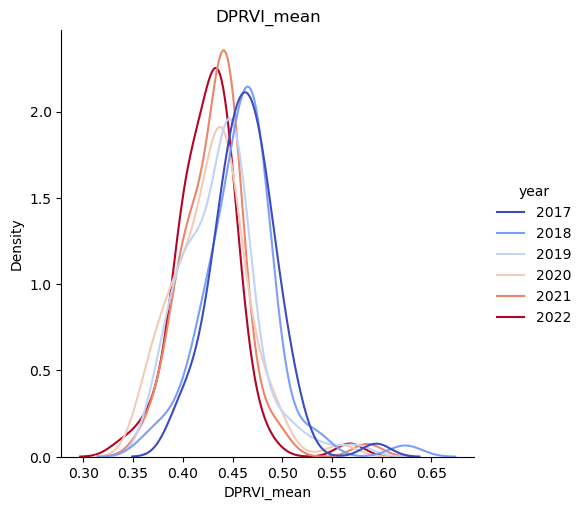

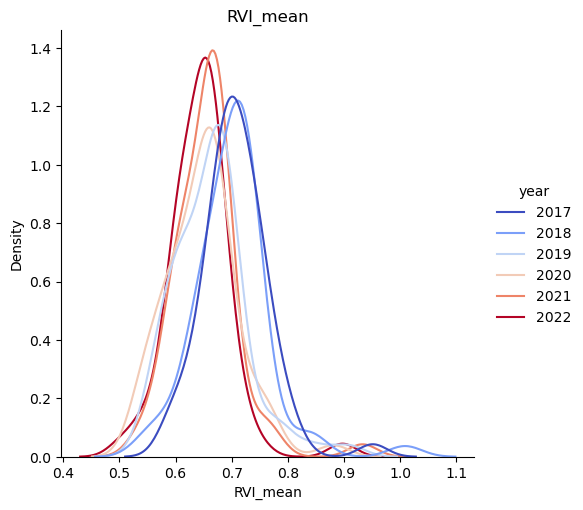

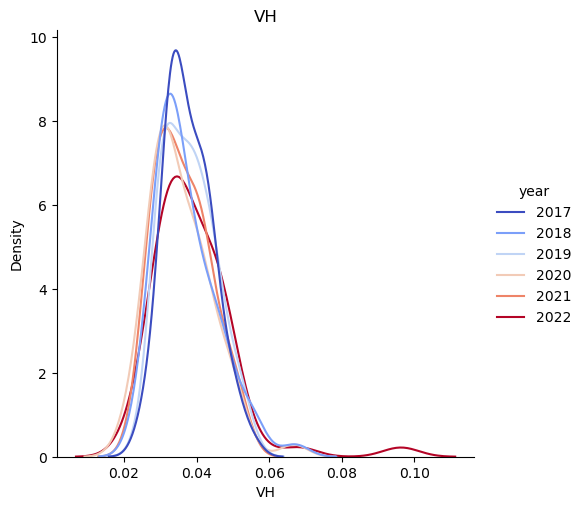

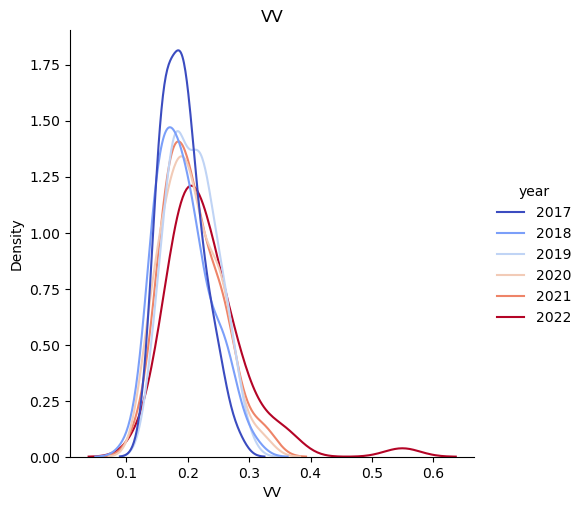

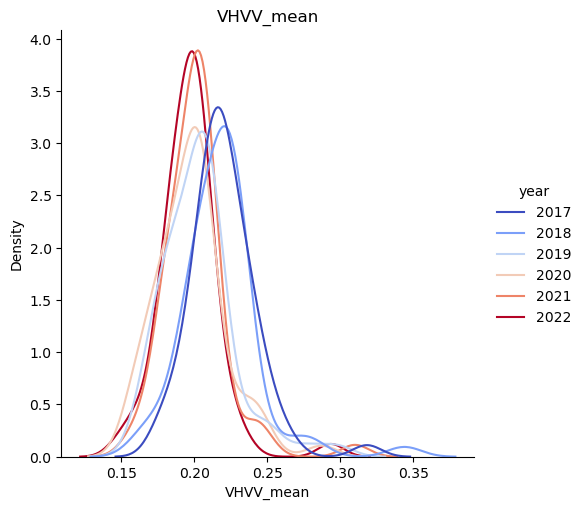

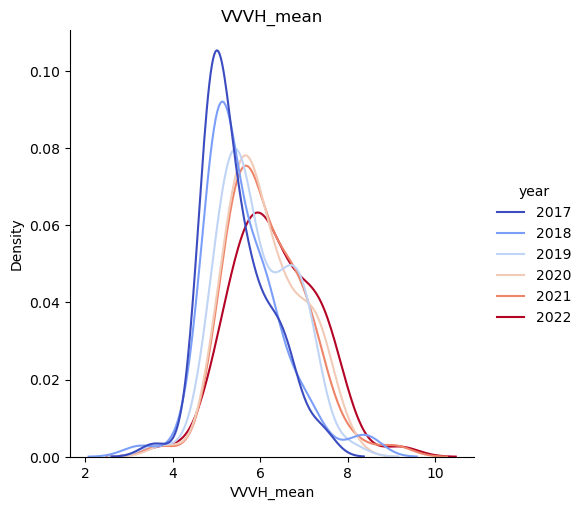

In [49]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    sns.displot(data=df_spring, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Autumn

In [67]:
df_autumn.describe()

,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
count,168.000000,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,53.971429,0.442700,0.671998,0.040350,0.222455,0.206257,5.739005
std,7.248301,0.024620,0.042191,0.008035,0.046912,0.015478,0.652966
min,34.000000,0.388672,0.583501,0.028501,0.126746,0.176221,4.566644
25%,50.200000,0.426483,0.644811,0.034485,0.188932,0.195996,5.272343
50%,55.700000,0.441324,0.668851,0.038241,0.218082,0.204616,5.667665
75%,58.225000,0.457763,0.697245,0.045906,0.244848,0.214973,6.143516
max,73.100000,0.517306,0.808210,0.066832,0.361456,0.260436,7.666153


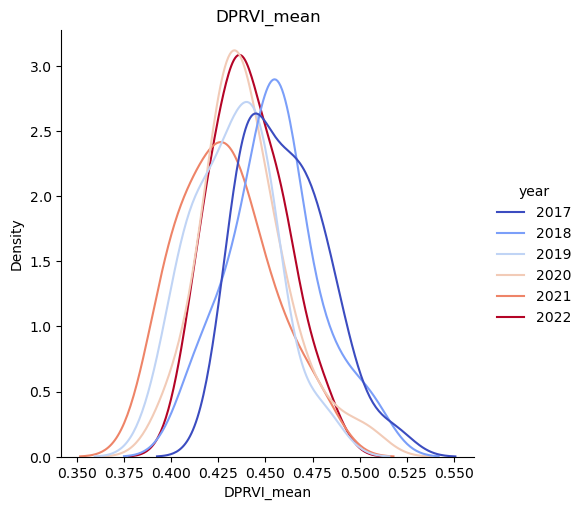

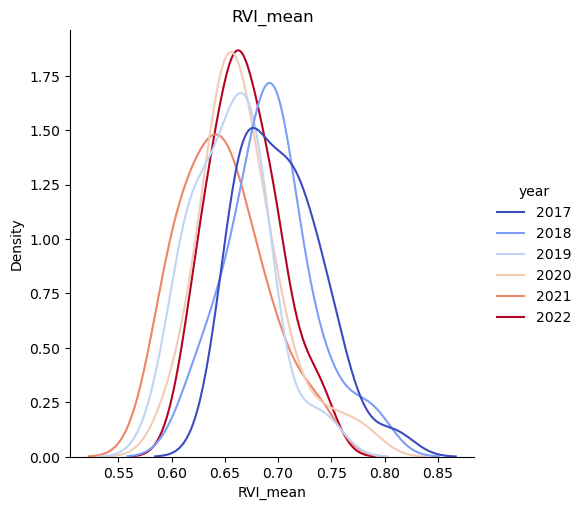

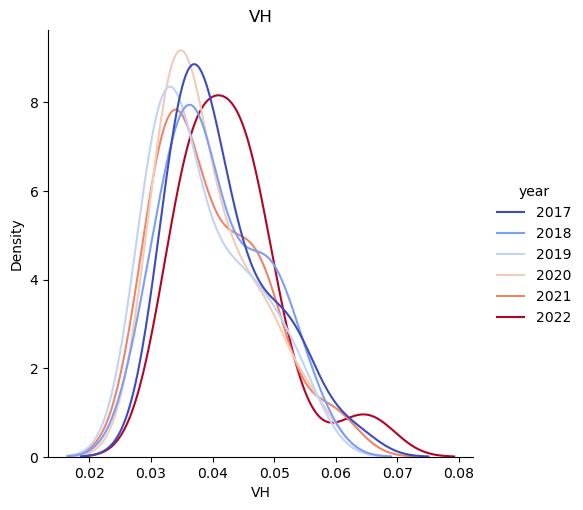

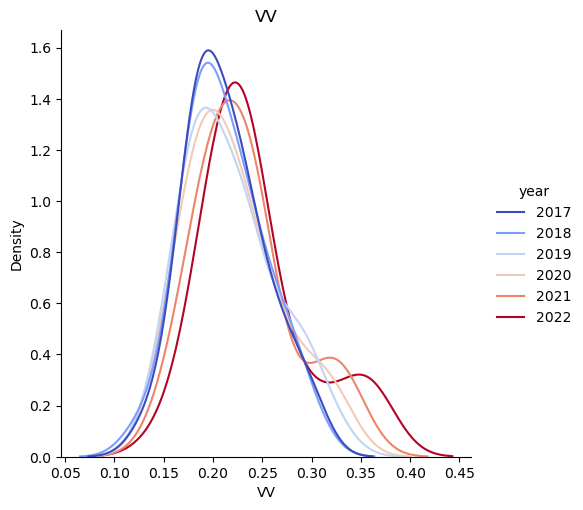

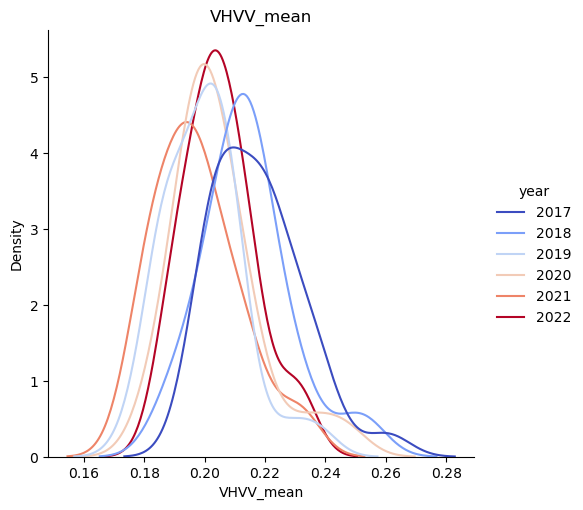

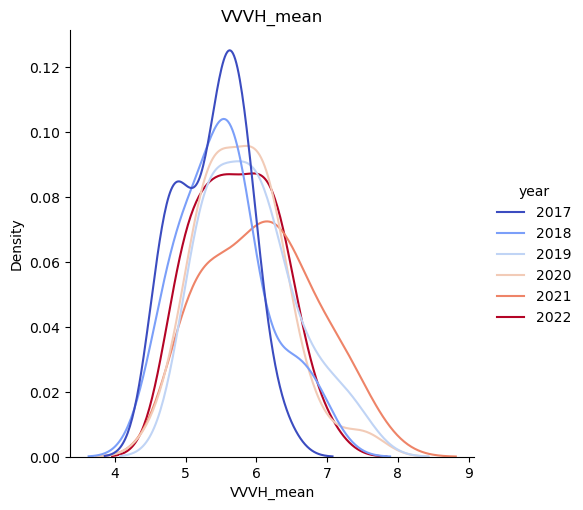

In [68]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    sns.displot(data=df_autumn, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Winter

In [44]:
df_winter.describe()

,year,winter_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
count,366.000000,336.000000,364.000000,364.000000,364.000000,364.000000,364.000000,364.000000
mean,2019.500000,45.230655,0.454521,0.691861,0.040721,0.216292,0.213250,5.517587
std,1.710163,12.763852,0.037746,0.064928,0.011429,0.060545,0.024033,1.080185
min,2017.000000,6.000000,0.224913,0.323122,0.012043,0.054503,0.090976,3.543571
25%,2018.000000,37.650000,0.432665,0.653361,0.035380,0.186014,0.199174,4.912832
50%,2019.500000,48.600000,0.455746,0.691716,0.043723,0.228640,0.211756,5.301777
75%,2021.000000,54.850000,0.475083,0.725237,0.048741,0.254696,0.224640,5.855192
max,2022.000000,65.000000,0.587458,0.936194,0.074831,0.396806,0.311250,15.742660


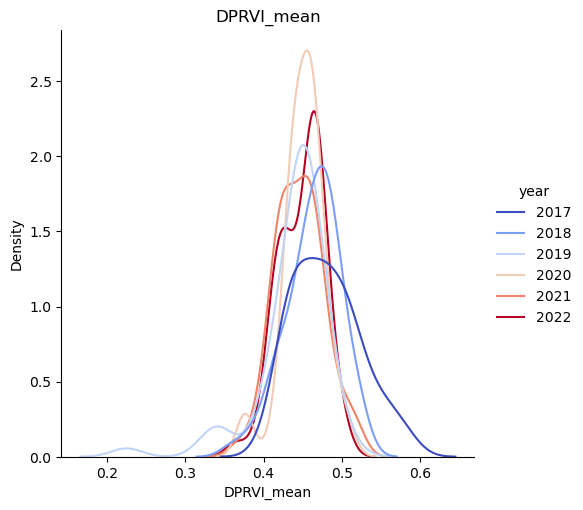

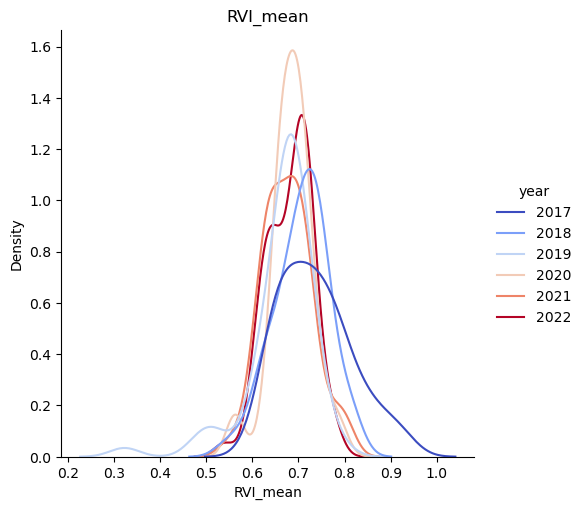

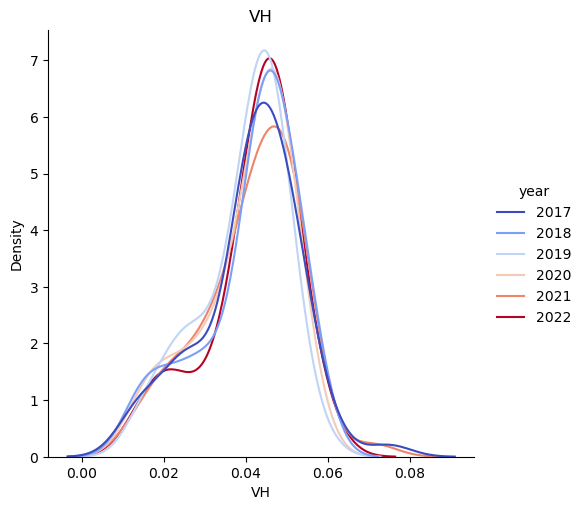

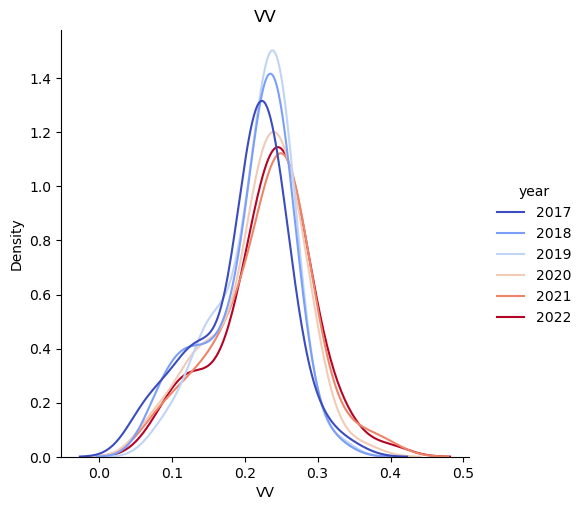

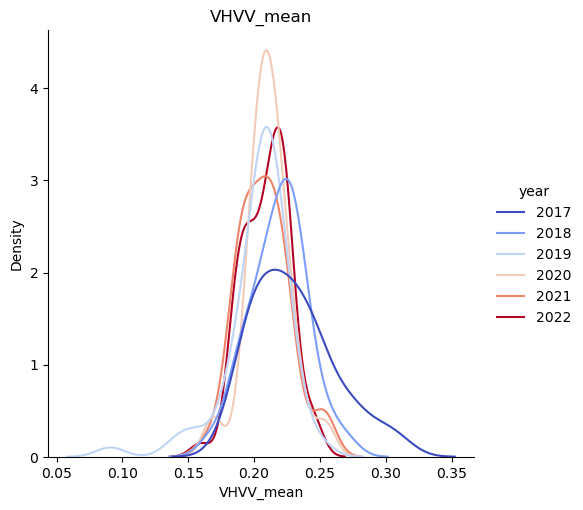

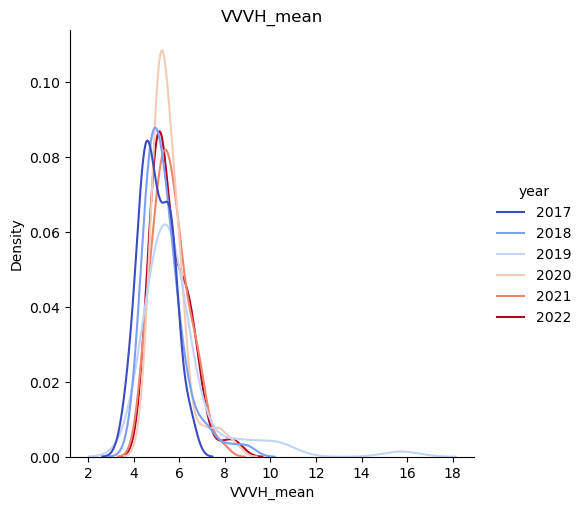

In [50]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    sns.displot(data=df_winter, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

### Total

In [46]:
df_total.describe()

,year,total_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
count,366.000000,366.000000,365.000000,365.000000,365.000000,365.000000,365.000000,365.000000
mean,2019.500000,55.468579,0.443328,0.673916,0.038928,0.212846,0.207419,5.820690
std,1.710163,8.015955,0.025298,0.044104,0.008212,0.046543,0.016718,0.673497
min,2017.000000,26.900000,0.367094,0.548405,0.021585,0.121008,0.164196,4.622829
25%,2018.000000,51.500000,0.427426,0.645734,0.033025,0.178474,0.197222,5.330498
50%,2019.500000,57.300000,0.443858,0.673624,0.037903,0.210420,0.206107,5.765554
75%,2021.000000,61.000000,0.458720,0.700356,0.045201,0.239385,0.216470,6.188546
max,2022.000000,71.200000,0.527855,0.832360,0.066821,0.373890,0.272671,8.315708


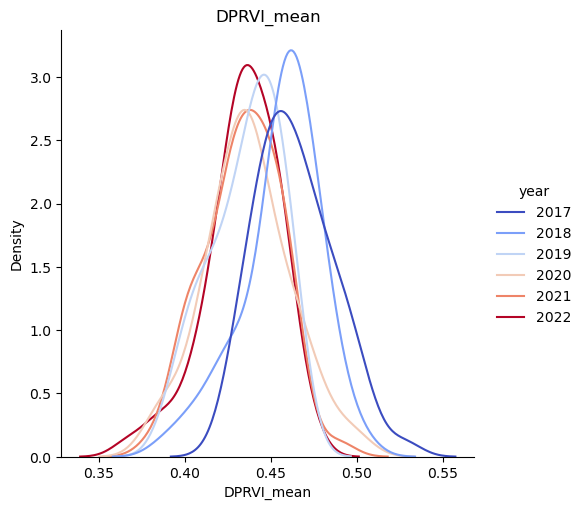

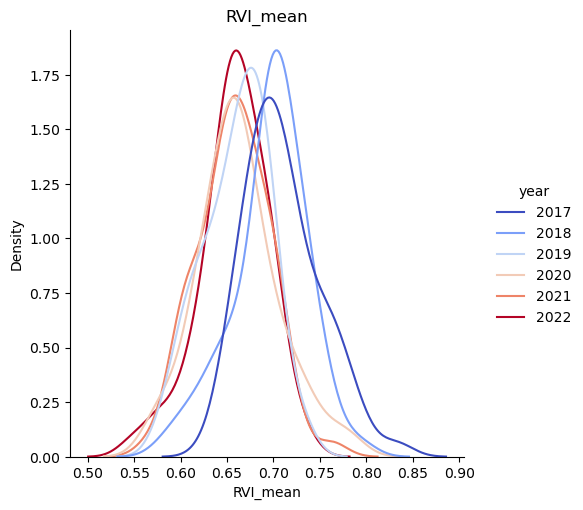

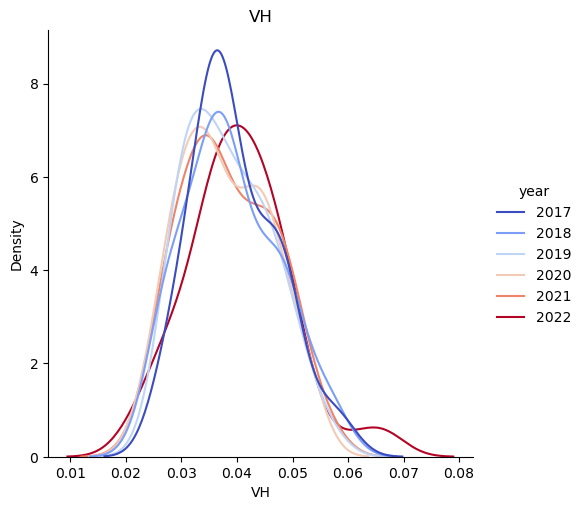

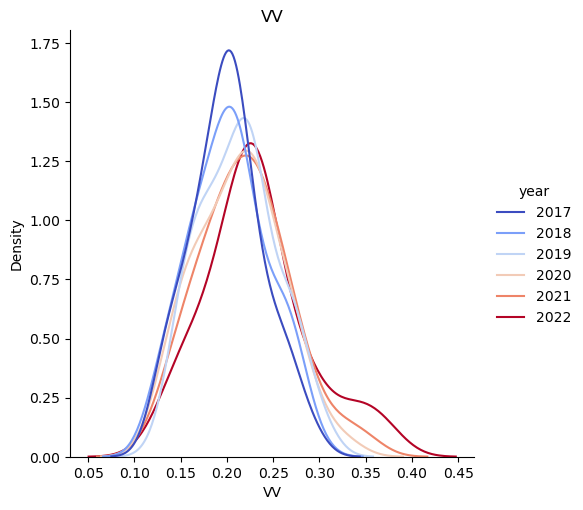

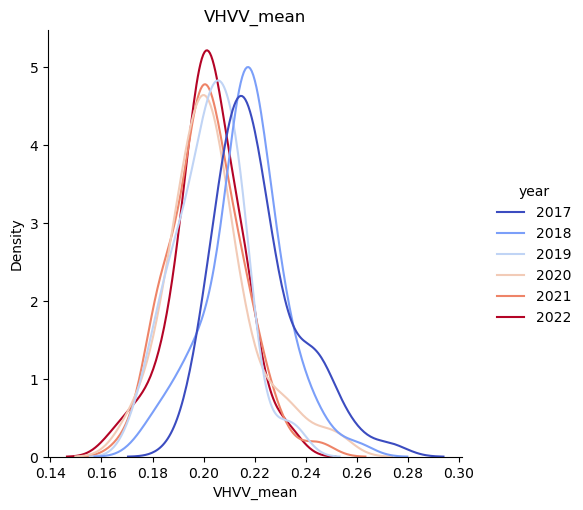

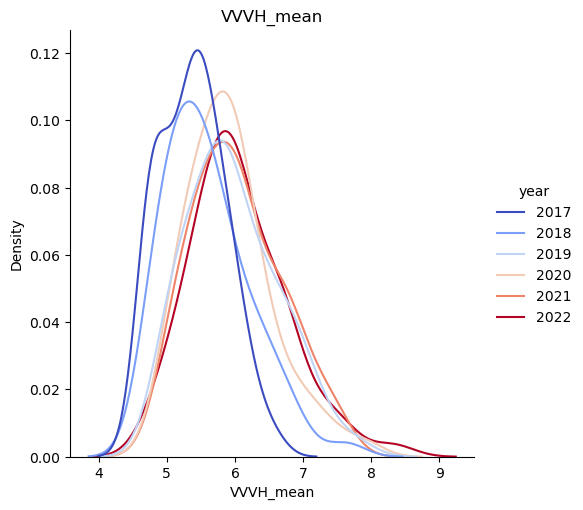

In [51]:
for indicator in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    sns.displot(data=df_total, x=indicator, kind="kde", hue='year', palette='coolwarm')
    plt.title(indicator)

In [52]:
df_total.columns

Index(['Province', 'year', 'total_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV',
       'VHVV_mean', 'VVVH_mean', 'season'],
      dtype='object')

## Modeling

In [53]:
import statsmodels.api as sm
import linearmodels as lm
from bs4 import BeautifulSoup
from stargazer.stargazer import Stargazer
from IPython.core.display import HTML

### Total

In [107]:
df_model = df_total[['Province', 'year', 'total_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,total_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Ha Noi,2017,55.4,0.472805,0.725736,0.048448,0.261199,0.227346,5.330498
1,Vinh Phuc,2017,55.3,0.509329,0.794233,0.035144,0.156315,0.255147,4.716743
2,Bac Ninh,2017,60.0,0.462125,0.702273,0.047424,0.240538,0.215637,5.167421
3,Quang Ninh,2017,47.1,0.434172,0.658552,0.031146,0.162999,0.202149,5.804464
4,Hai Duong,2017,55.7,0.467882,0.710589,0.049223,0.233753,0.217792,4.850965
...,...,...,...,...,...,...,...,...,...
360,Can Tho,2022,63.2,0.432578,0.652951,0.042024,0.257358,0.198570,5.934130
361,Hau Giang,2022,66.6,0.456805,0.696534,0.040100,0.194281,0.215268,5.561314
362,Soc Trang,2022,61.4,0.423064,0.641968,0.032433,0.185688,0.197236,6.578427
363,Bac Lieu,2022,63.4,0.441715,0.668982,0.046749,0.230861,0.204125,4.830776


In [110]:
Y = df_model['total_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
      print(x)
      X = sm.add_constant(df_model[x])
      model = sm.OLS(Y, X)
      results = model.fit(cov_type='HC1')
#       print(results.summary())
      print(round(results.rsquared, 4))
      print('\n')

DPRVI_mean
0.0012


RVI_mean
0.0006


VH
0.0166


VV
0.0115


VHVV_mean
0.0001


VVVH_mean
0.013




In [112]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['total_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    print(x)
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(round(results.rsquared, 4))
    print('\n')

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.3961


RVI_mean
0.3961


VH
0.3961


VV
0.3961


VHVV_mean
0.3961


VVVH_mean
0.3966




In [113]:
# year = pd.Categorical(df_model['year'])
# X = df_model.set_index(['Province', 'year'])
# X['year'] = year
# Y = X['total_production']
# for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
#        'VVVH_mean']:
#     print(x)
    
#     model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
#     results = model.fit(cov_type='clustered', cluster_entity=True)

#     print(results.summary)
#     print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

### Spring yield

#### All Spring

In [116]:
df_model = df_spring[['Province', 'year', 'spring_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Ha Noi,2017,61.3,0.458881,0.701201,0.046779,0.260424,0.218027,5.584812
1,Vinh Phuc,2017,61.1,0.509415,0.794854,0.039767,0.170284,0.255698,4.679710
2,Bac Ninh,2017,64.4,0.473456,0.722586,0.044844,0.221362,0.223474,4.998987
3,Quang Ninh,2017,54.8,0.436898,0.661294,0.029605,0.150069,0.201996,5.665778
4,Hai Duong,2017,65.1,0.450499,0.679688,0.044687,0.222572,0.206062,5.082163
...,...,...,...,...,...,...,...,...,...
359,Can Tho,2022,74.2,0.424947,0.639769,0.041272,0.260548,0.193726,6.073419
360,Hau Giang,2022,77.8,0.432862,0.657446,0.036049,0.186085,0.202080,6.279962
361,Soc Trang,2022,67.1,0.411293,0.626944,0.032392,0.188163,0.194427,7.355425
362,Bac Lieu,2022,75.7,0.438568,0.663280,0.047516,0.238449,0.201911,4.904114


In [117]:
Y = df_model['spring_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')

    print(x)
    print(round(results.rsquared, 4))
   #  print(results.summary())

DPRVI_mean
0.0004
RVI_mean
0.0002
VH
0.0099
VV
0.0054
VHVV_mean
0.0
VVVH_mean
0.0096


In [118]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.1323
RVI_mean
0.1323
VH
0.132
VV
0.132
VHVV_mean
0.1323
VVVH_mean
0.132


#### Early Spring

In [119]:
df_model = df_early_spring[['Province', 'year', 'spring_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Ha Noi,2017,61.3,0.461885,0.706971,0.044171,0.243656,0.220519,5.598487
1,Vinh Phuc,2017,61.1,0.507887,0.790344,0.037674,0.163262,0.252835,4.679610
2,Bac Ninh,2017,64.4,0.443600,0.669512,0.041633,0.220881,0.203278,5.444993
3,Quang Ninh,2017,54.8,0.407637,0.611174,0.024762,0.138035,0.183837,6.216025
4,Hai Duong,2017,65.1,0.440467,0.662848,0.042818,0.218515,0.200178,5.263997
...,...,...,...,...,...,...,...,...,...
359,Can Tho,2022,74.2,0.400747,0.597961,0.039752,0.267589,0.178413,6.504694
360,Hau Giang,2022,77.8,0.363448,0.540641,0.027687,0.177423,0.160675,8.077217
361,Soc Trang,2022,67.1,0.298113,0.435869,0.021805,0.186099,0.126235,10.277485
362,Bac Lieu,2022,75.7,0.443828,0.672234,0.046097,0.228767,0.205121,4.842510


In [120]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.1325
RVI_mean
0.1326
VH
0.1349
VV
0.1322
VHVV_mean
0.1326
VVVH_mean
0.1322


#### Late Spring

In [121]:
df_model = df_late_spring[['Province', 'year', 'spring_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,spring_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Ha Noi,2017,61.3,0.455877,0.695430,0.049387,0.277192,0.215534,5.571138
1,Vinh Phuc,2017,61.1,0.510943,0.799364,0.041860,0.177305,0.258561,4.679810
2,Bac Ninh,2017,64.4,0.503311,0.775660,0.048055,0.221842,0.243669,4.552982
3,Quang Ninh,2017,54.8,0.466159,0.711414,0.034449,0.162102,0.220155,5.115532
4,Hai Duong,2017,65.1,0.460531,0.696528,0.046557,0.226628,0.211945,4.900329
...,...,...,...,...,...,...,...,...,...
359,Can Tho,2022,74.2,0.449148,0.681577,0.042792,0.253508,0.209040,5.642145
360,Hau Giang,2022,77.8,0.502276,0.774251,0.044411,0.194748,0.243485,4.482707
361,Soc Trang,2022,67.1,0.524473,0.818019,0.042980,0.190227,0.262619,4.433365
362,Bac Lieu,2022,75.7,0.433309,0.654326,0.048936,0.248131,0.198702,4.965717


In [122]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['spring_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.1337
RVI_mean
0.1337
VH
0.1324
VV
0.132
VHVV_mean
0.1338
VVVH_mean
0.132


### Autumn yield

#### All Autumn

In [123]:
df_model = df_autumn[['Province', 'year', 'autumn_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Nghe An,2017,48.7,0.468398,0.712744,0.053746,0.253642,0.219213,4.910232
1,Ha Tinh,2017,44.9,0.442313,0.672436,0.041567,0.214785,0.206872,5.871011
2,Quang Binh,2017,40.2,0.441985,0.670306,0.035675,0.187564,0.205416,5.625326
3,Quang Tri,2017,42.3,0.437807,0.666864,0.033346,0.175517,0.206179,5.941067
4,Thua Thien Hue,2017,57.8,0.435053,0.656625,0.040282,0.237610,0.199440,5.788372
...,...,...,...,...,...,...,...,...,...
163,Can Tho,2022,57.2,0.441175,0.668374,0.042869,0.254118,0.204528,5.818307
164,Hau Giang,2022,58.9,0.483645,0.741285,0.042793,0.197166,0.230856,4.839709
165,Soc Trang,2022,54.7,0.422691,0.639355,0.033683,0.194146,0.195234,6.384868
166,Bac Lieu,2022,58.6,0.438245,0.663350,0.046536,0.231078,0.202253,4.888167


In [124]:
Y = df_model['autumn_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

DPRVI_mean
0.0184
RVI_mean
0.0254
VH
0.0176
VV
0.0059
VHVV_mean
0.0371
VVVH_mean
0.0014


In [125]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.2383
RVI_mean
0.2384
VH
0.2678
VV
0.2611
VHVV_mean
0.2387
VVVH_mean
0.239


#### Main Autumn

In [126]:
df_model = df_main_autumn[['Province', 'year', 'autumn_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Nghe An,2017,48.7,0.445239,0.672361,0.051466,0.258397,0.204238,5.282248
1,Ha Tinh,2017,44.9,0.413679,0.623062,0.038421,0.215071,0.188748,6.475158
2,Quang Binh,2017,40.2,0.447463,0.681065,0.034427,0.175756,0.210045,5.620669
3,Quang Tri,2017,42.3,0.396671,0.595485,0.027641,0.165639,0.179686,6.762123
4,Thua Thien Hue,2017,57.8,0.431527,0.650597,0.040928,0.242638,0.197236,5.865095
...,...,...,...,...,...,...,...,...,...
158,Kien Giang,2022,56.1,0.442135,0.670721,0.038251,0.231880,0.205650,5.790595
159,Can Tho,2022,57.2,0.438011,0.663266,0.042779,0.255255,0.202846,5.901598
160,Soc Trang,2022,54.7,0.403659,0.608622,0.034636,0.208729,0.184956,6.989877
161,Bac Lieu,2022,58.6,0.429519,0.648243,0.046185,0.235647,0.196735,5.065853


In [127]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.2205
RVI_mean
0.2206
VH
0.2479
VV
0.2312
VHVV_mean
0.2206
VVVH_mean
0.2233


#### Late Autumn

In [128]:
df_model = df_late_autumn[['Province', 'year', 'autumn_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,autumn_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Nghe An,2017,48.7,0.491558,0.753127,0.056026,0.248888,0.234189,4.538216
1,Ha Tinh,2017,44.9,0.470947,0.721809,0.044713,0.214498,0.224997,5.266863
2,Quang Binh,2017,40.2,0.436507,0.659546,0.036922,0.199372,0.200786,5.629983
3,Quang Tri,2017,42.3,0.478943,0.738244,0.039052,0.185396,0.232672,5.120011
4,Thua Thien Hue,2017,57.8,0.438579,0.662653,0.039636,0.232581,0.201644,5.711649
...,...,...,...,...,...,...,...,...,...
163,Can Tho,2022,57.2,0.444339,0.673482,0.042959,0.252980,0.206211,5.735017
164,Hau Giang,2022,58.9,0.483645,0.741285,0.042793,0.197166,0.230856,4.839709
165,Soc Trang,2022,54.7,0.441724,0.670088,0.032730,0.179563,0.205511,5.779859
166,Bac Lieu,2022,58.6,0.446971,0.678457,0.046887,0.226509,0.207770,4.710481


In [129]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['autumn_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.2627
RVI_mean
0.264
VH
0.256
VV
0.2647
VHVV_mean
0.2662
VVVH_mean
0.2463


### Winter yield

In [130]:
df_model = df_winter[['Province', 'year', 'winter_yield', 'DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean', 'VVVH_mean']]
df_model = df_model.dropna().reset_index(drop=True)
df_model

,Province,year,winter_yield,DPRVI_mean,RVI_mean,VH,VV,VHVV_mean,VVVH_mean
0,Ha Noi,2017,49.1,0.497808,0.770902,0.049061,0.248936,0.245099,4.930578
1,Vinh Phuc,2017,48.6,0.567821,0.898418,0.027752,0.108915,0.295246,3.759969
2,Bac Ninh,2017,55.6,0.467368,0.710069,0.049495,0.244304,0.217809,5.007658
3,Quang Ninh,2017,42.0,0.437586,0.666025,0.036371,0.192181,0.205894,5.805775
4,Hai Duong,2017,46.2,0.502172,0.770567,0.054248,0.235808,0.240078,4.334944
...,...,...,...,...,...,...,...,...,...
329,An Giang,2022,42.1,0.493635,0.764085,0.037528,0.178205,0.242227,5.076664
330,Kien Giang,2022,53.8,0.436231,0.657478,0.042298,0.253426,0.199232,5.673713
331,Soc Trang,2022,50.9,0.447350,0.677243,0.030012,0.163822,0.206861,5.411548
332,Bac Lieu,2022,60.7,0.454951,0.691649,0.045642,0.215250,0.212299,4.569317


In [133]:
Y = df_model['winter_yield']

for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    X = sm.add_constant(df_model[x])
    model = sm.OLS(Y, X)
    results = model.fit(cov_type='HC1')
   #  print(results.summary())
    print(x)
    print(round(results.rsquared, 4))

DPRVI_mean
0.0001
RVI_mean
0.0002
VH
0.0036
VV
0.0022
VHVV_mean
0.0002
VVVH_mean
0.0


In [134]:
year = pd.Categorical(df_model['year'])
X = df_model.set_index(['Province', 'year'])
X['year'] = year
Y = X['winter_yield']
for x in ['DPRVI_mean', 'RVI_mean', 'VH', 'VV', 'VHVV_mean',
       'VVVH_mean']:
    
    model = lm.PanelOLS(Y, X[[x, 'year']], entity_effects=True)
    results = model.fit(cov_type='clustered', cluster_entity=True)

    # print(results.summary)
    print(x)
    print(round(results.rsquared, 4))

# stargazer = Stargazer([full_log])
# HTML(stargazer.render_html())

DPRVI_mean
0.2857
RVI_mean
0.2856
VH
0.2841
VV
0.2845
VHVV_mean
0.2855
VVVH_mean
0.2856
